# Module 2 — Calcul nutritionnel et détection des déséquilibres

Estimation des apports nutritionnels à partir des aliments détectés par le Module 1.
**Dataset** : Nutritional Facts for most common foods (Kaggle, niharika41298, CC0, 335 aliments)

## Contexte

Après que le Module 1 identifie les aliments dans une photo, le Module 2 calcule les apports nutritionnels correspondants.

### Approche choisie : Recherche dans une base de données nutritionnelle
Plutôt que d'utiliser un modèle ML pour estimer les calories, nous utilisons une **base de données nutritionnelle réelle** (Kaggle).
Cette approche est plus fiable car les valeurs nutritionnelles sont des données factuelles — un modèle ML n'apporterait pas de valeur ajoutée ici.

### Ce que fait ce module
1. Charger et nettoyer le dataset nutritionnel
2. Rechercher chaque aliment détecté dans la base
3. Calculer les totaux (calories, protéines, glucides, lipides)
4. Détecter les déséquilibres selon l'objectif utilisateur

## 1. Chargement du dataset

Le dataset **Nutritional Facts for most common foods** contient 335 aliments avec leurs valeurs nutritionnelles pour une portion standard.
Licence CC0 (domaine public) — téléchargé via l'API Kaggle.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/nutrition/nutrients_csvfile.csv")

print("Shape:", df.shape)
print("\nColonnes:", df.columns.tolist())
print("\nAperçu:")
df.head()

Shape: (335, 10)

Colonnes: ['Food', 'Measure', 'Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs', 'Category']

Aperçu:


,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products


## 2. Exploration du dataset (EDA)

Avant de nettoyer les données, on explore leur structure pour comprendre ce qu'on manipule.

In [3]:
# Nettoyage
print("Valeurs manquantes:")
print(df.isnull().sum())
print("\nValeurs uniques 'Measure':", df['Measure'].nunique())
print("\nCatégories:", df['Category'].unique())

Valeurs manquantes:
Food        0
Measure     0
Grams       0
Calories    1
Protein     0
Fat         0
Sat.Fat     2
Fiber       0
Carbs       0
Category    0
dtype: int64

Valeurs uniques 'Measure': 61

Catégories: <ArrowStringArray>
[                  'Dairy products',          'Fats, Oils, Shortenings',
                    'Meat, Poultry',                    'Fish, Seafood',
                   'Vegetables A-E',                   'Vegetables F-P',
                   'Vegetables R-Z',                       'Fruits A-F',
                       'Fruits G-P',                       'Fruits R-Z',
 'Breads, cereals, fastfood,grains',                            'Soups',
                 'Desserts, sweets',                    'Jams, Jellies',
                   'Seeds and Nuts',        'Drinks,Alcohol, Beverages']
Length: 16, dtype: str


### Interprétation
- **335 aliments** répartis en **16 catégories** (fruits, légumes, viandes, produits laitiers...)
- Colonnes clés : `Food`, `Measure`, `Grams`, `Calories`, `Protein`, `Fat`, `Sat.Fat`, `Fiber`, `Carbs`, `Category`
- La colonne `Measure` indique la portion de référence (ex: '1 cup', '1 qt.') — on normalisera tout à 100g
- Valeur `'t'` = trace (quantité négligeable) → à remplacer par 0

In [2]:
# Nettoyage des données
df_clean = df.copy()

# Remplacer 't' (trace) par 0
df_clean = df_clean.replace('t', 0)

# Convertir les colonnes numériques
numeric_cols = ['Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Supprimer les virgules dans les nombres (ex: 1,419)
for col in numeric_cols:
    if df_clean[col].dtype == object:
        df_clean[col] = df_clean[col].str.replace(',', '').astype(float)

# Remplir les valeurs manquantes avec la médiane
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print("Après nettoyage:")
print(df_clean.isnull().sum())
print("\nAperçu:")
df_clean.head()

Après nettoyage:
Food        0
Measure     0
Grams       0
Calories    0
Protein     0
Fat         0
Sat.Fat     0
Fiber       0
Carbs       0
Category    0
dtype: int64

Aperçu:


,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976.0,660.0,32,40.0,36.0,0.0,48.0,Dairy products
1,Milk skim,1 qt.,984.0,360.0,36,0.0,0.0,0.0,52.0,Dairy products
2,Buttermilk,1 cup,246.0,127.0,9,5.0,4.0,0.0,13.0,Dairy products
3,"Evaporated, undiluted",1 cup,252.0,345.0,16,20.0,18.0,0.0,24.0,Dairy products
4,Fortified milk,6 cups,108.0,130.0,89,42.0,23.0,1.4,119.0,Dairy products


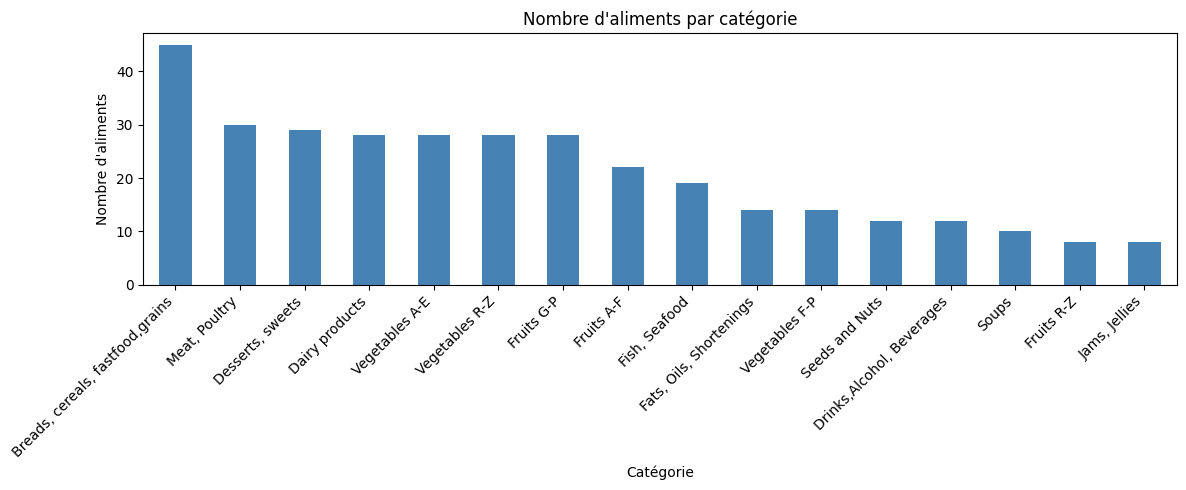

Catégorie la plus représentée : Breads, cereals, fastfood,grains (45 aliments)
Catégorie la moins représentée : Jams, Jellies (8 aliments)


In [4]:
import matplotlib.pyplot as plt

# Distribution par catégorie
cat_counts = df['Category'].value_counts()

plt.figure(figsize=(12, 5))
cat_counts.plot(kind='bar', color='steelblue')
plt.title("Nombre d'aliments par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'aliments")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Catégorie la plus représentée : {cat_counts.index[0]} ({cat_counts.iloc[0]} aliments)")
print(f"Catégorie la moins représentée : {cat_counts.index[-1]} ({cat_counts.iloc[-1]} aliments)")

### Interprétation de la distribution par catégorie
Les catégories les mieux représentées sont les fruits, légumes et viandes — ce qui correspond bien aux aliments que notre Module 1 détecte.
Les catégories moins représentées (Jams, Seeds) sont moins critiques pour notre usage.

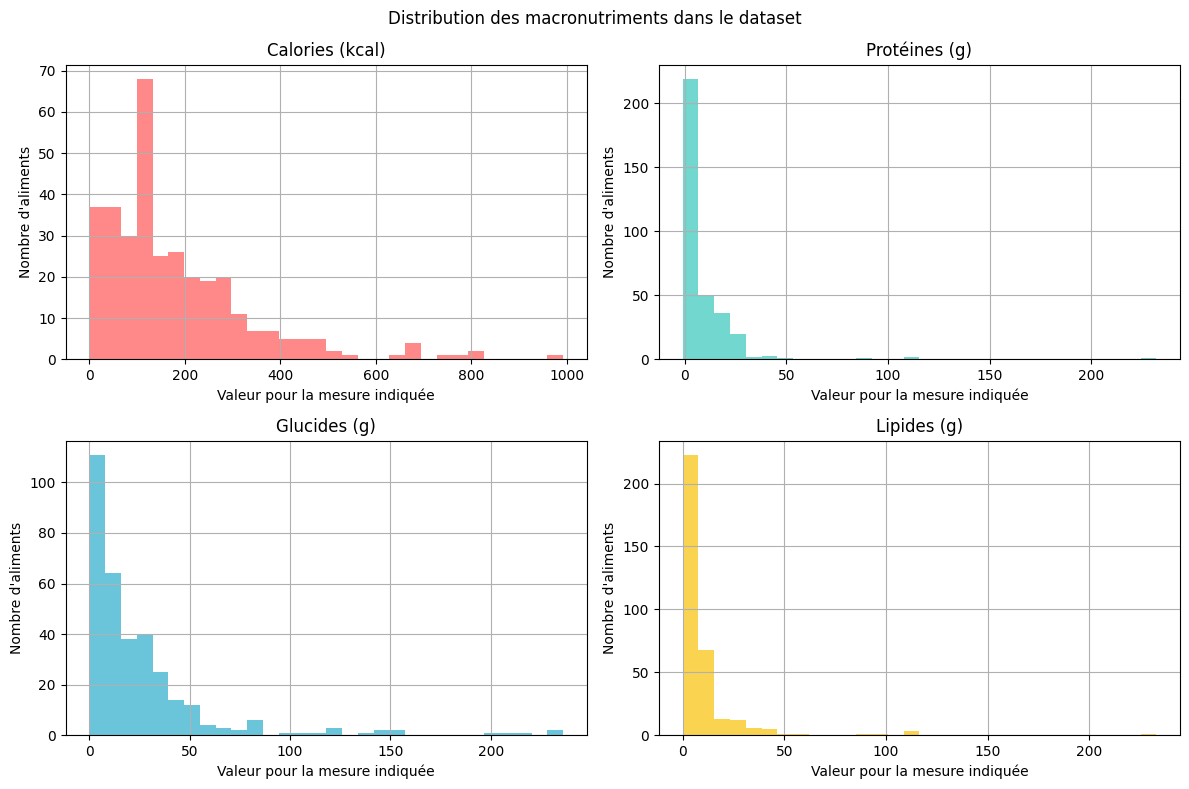

In [5]:
# Distribution des macronutriments
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, color, title in zip(
    axes.flatten(),
    ['Calories', 'Protein', 'Carbs', 'Fat'],
    ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24'],
    ['Calories (kcal)', 'Protéines (g)', 'Glucides (g)', 'Lipides (g)']
):
    df_clean[col].dropna().hist(ax=ax, bins=30, color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Valeur pour la mesure indiquée")
    ax.set_ylabel("Nombre d'aliments")

plt.suptitle("Distribution des macronutriments dans le dataset")
plt.tight_layout()
plt.show()

### Interprétation des distributions
- **Calories** : distribution asymétrique — la plupart des aliments ont moins de 500 kcal par portion
- **Protéines** : la majorité des aliments ont moins de 30g de protéines par portion
- **Glucides** : forte variabilité — certains aliments (pains, céréales) sont très riches en glucides
- **Lipides** : distribution asymétrique — quelques aliments sont très riches en graisses (huiles, noix)

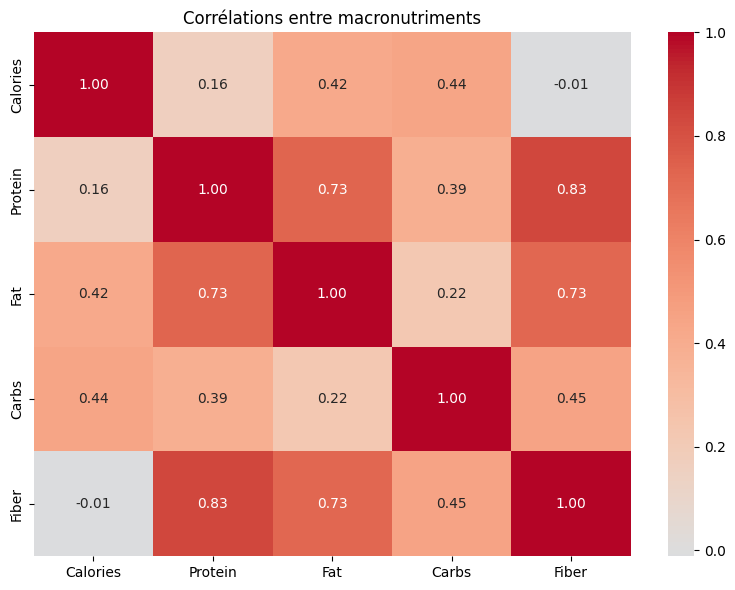

In [6]:
# Corrélations entre macronutriments
import seaborn as sns

corr = df_clean[['Calories', 'Protein', 'Fat', 'Carbs', 'Fiber']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Corrélations entre macronutriments")
plt.tight_layout()
plt.show()

### Interprétation des corrélations
- **Calories ↔ Fat** : corrélation forte — les lipides sont la source d'énergie la plus dense (9 kcal/g vs 4 pour les glucides/protéines)
- **Calories ↔ Carbs** : corrélation modérée
- **Fiber ↔ Carbs** : corrélation attendue — les fibres sont des glucides non digestibles

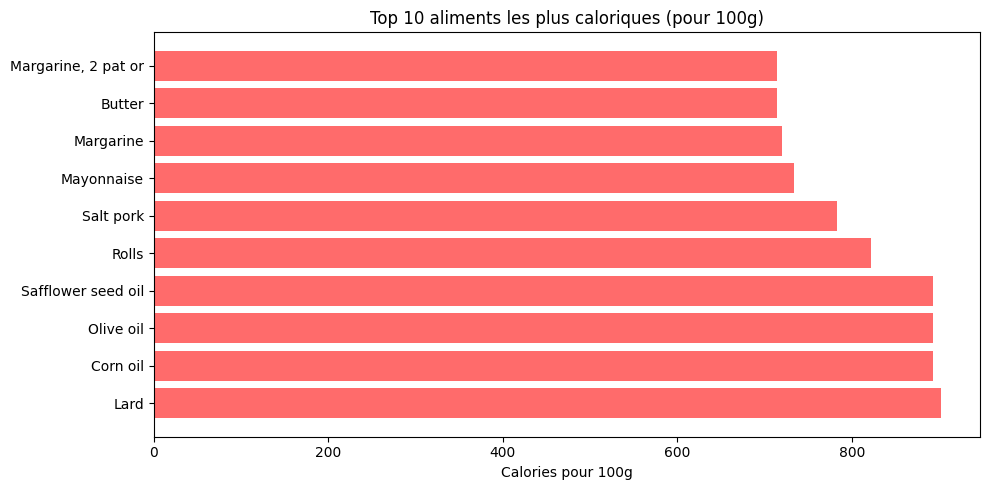

               Food  cal_per_100g                         Category
               Lard    901.818182          Fats, Oils, Shortenings
           Corn oil    892.857143          Fats, Oils, Shortenings
          Olive oil    892.857143          Fats, Oils, Shortenings
 Safflower seed oil    892.857143          Fats, Oils, Shortenings
              Rolls    822.000000 Breads, cereals, fastfood,grains
          Salt pork    783.333333                    Meat, Poultry
         Mayonnaise    733.333333          Fats, Oils, Shortenings
          Margarine    719.642857          Fats, Oils, Shortenings
             Butter    714.285714          Fats, Oils, Shortenings
Margarine, 2 pat or    714.285714          Fats, Oils, Shortenings


In [7]:
# Top 10 aliments les plus caloriques (normalisés à 100g)
df_norm = df_clean.copy()
df_norm['cal_per_100g'] = (df_norm['Calories'] / df_norm['Grams'].replace(0, 100)) * 100

top10 = df_norm.nlargest(10, 'cal_per_100g')[['Food', 'cal_per_100g', 'Category']]

plt.figure(figsize=(10, 5))
plt.barh(top10['Food'], top10['cal_per_100g'], color='#ff6b6b')
plt.title("Top 10 aliments les plus caloriques (pour 100g)")
plt.xlabel("Calories pour 100g")
plt.tight_layout()
plt.show()

print(top10.to_string(index=False))

## 3. Nettoyage des données

### Problèmes identifiés
- Valeur `'t'` (trace) dans certaines colonnes numériques → remplacée par 0
- Virgules dans les grands nombres (ex: `1,419`) → supprimées
- 1 valeur manquante dans Calories et 2 dans Sat.Fat → remplacement par la médiane
- Normalisation à 100g : chaque aliment a une portion de référence différente

### Résultat du nettoyage
Après nettoyage :
- **0 valeur manquante** dans toutes les colonnes
- Toutes les colonnes numériques sont bien typées
- Les valeurs sont normalisées pour permettre la comparaison entre aliments

## 4. Fonction estimate_nutrition()

Cette fonction prend en entrée une liste d'aliments détectés et retourne leurs valeurs nutritionnelles.

### Algorithme
1. Pour chaque aliment détecté, recherche approximative dans le dataset (`.str.contains()`)
2. Si trouvé : normalise les valeurs à 100g en divisant par la portion de référence
3. Calcule les totaux

### Limite identifiée
La recherche par `str.contains()` est approximative — 'orange' peut trouver 'Oranges 3" diameter'.
C'est un compromis acceptable pour notre prototype.

In [8]:
def estimate_nutrition(detected_foods, portion="standard"):
    """
    Estime les apports nutritionnels à partir d'une liste d'aliments détectés.
    
    Args:
        detected_foods: liste de labels détectés par le Module 1
        portion: "standard" (100g par défaut)
    
    Returns:
        dict avec calories, macros et déséquilibres détectés
    """
    results = []
    
    for food_label in detected_foods:
        # Recherche approximative dans le dataset
        matches = df_clean[df_clean['Food'].str.lower().str.contains(food_label.lower(), na=False)]
        
        if not matches.empty:
            row = matches.iloc[0]
            grams = row['Grams'] if row['Grams'] > 0 else 100
            factor = 100 / grams  # Normalise à 100g
            
            results.append({
                "food": food_label,
                "found_as": row['Food'],
                "calories_per_100g": round(row['Calories'] * factor, 1),
                "protein_per_100g": round(row['Protein'] * factor, 1),
                "carbs_per_100g": round(row['Carbs'] * factor, 1),
                "fat_per_100g": round(row['Fat'] * factor, 1),
                "fiber_per_100g": round(row['Fiber'] * factor, 1),
            })
        else:
            results.append({
                "food": food_label,
                "found_as": None,
                "calories_per_100g": None,
                "protein_per_100g": None,
                "carbs_per_100g": None,
                "fat_per_100g": None,
                "fiber_per_100g": None,
            })
    
    # Calcul des totaux
    found = [r for r in results if r['calories_per_100g'] is not None]
    
    if not found:
        return {"error": "Aucun aliment reconnu dans la base nutritionnelle"}
    
    total_calories = sum(r['calories_per_100g'] for r in found)
    total_protein = sum(r['protein_per_100g'] for r in found)
    total_carbs = sum(r['carbs_per_100g'] for r in found)
    total_fat = sum(r['fat_per_100g'] for r in found)
    
    return {
        "detected_foods": results,
        "totals": {
            "calories": round(total_calories, 1),
            "protein_g": round(total_protein, 1),
            "carbs_g": round(total_carbs, 1),
            "fat_g": round(total_fat, 1),
        }
    }

print("Fonction estimate_nutrition() prête !")

Fonction estimate_nutrition() prête !


## 5. Test — Repas équilibré (banana, tomato, orange)

In [9]:
# Test avec des aliments détectés par le Module 1
test_foods = ["banana", "tomato", "orange"]

result = estimate_nutrition(test_foods)

print("=== Résultat estimate_nutrition ===\n")
for food in result["detected_foods"]:
    print(f"Aliment : {food['food']}")
    print(f"  Trouvé comme : {food['found_as']}")
    print(f"  Calories/100g : {food['calories_per_100g']}")
    print(f"  Protéines/100g : {food['protein_per_100g']}g")
    print(f"  Glucides/100g : {food['carbs_per_100g']}g")
    print(f"  Lipides/100g : {food['fat_per_100g']}g")
    print()

print("=== Totaux ===")
print(f"Calories : {result['totals']['calories']} kcal")
print(f"Protéines : {result['totals']['protein_g']}g")
print(f"Glucides : {result['totals']['carbs_g']}g")
print(f"Lipides : {result['totals']['fat_g']}g")

=== Résultat estimate_nutrition ===

Aliment : banana
  Trouvé comme : Banana
  Calories/100g : 56.7
  Protéines/100g : 0.7g
  Glucides/100g : 15.3g
  Lipides/100g : 0.0g

Aliment : tomato
  Trouvé comme : Tomatoes
  Calories/100g : 20.8
  Protéines/100g : 0.8g
  Glucides/100g : 3.8g
  Lipides/100g : 0.0g

Aliment : orange
  Trouvé comme : Oranges 3" diameter
  Calories/100g : 33.3
  Protéines/100g : 1.1g
  Glucides/100g : 8.9g
  Lipides/100g : 0.0g

=== Totaux ===
Calories : 110.8 kcal
Protéines : 2.6g
Glucides : 28.0g
Lipides : 0.0g


### Interprétation
Ce repas de 3 fruits légers totalise environ **110 kcal** — très peu calorique, riche en glucides naturels (sucres des fruits).
Les protéines et lipides sont quasi absents, ce qui est normal pour des fruits.

## 6. Fonction detect_imbalances()

Détecte les déséquilibres nutritionnels selon l'objectif de l'utilisateur.

### Seuils définis
| Objectif | Critère | Seuil |
|----------|---------|-------|
| Perte de poids | Calories max | 400 kcal |
| Perte de poids | Glucides max | 50g |
| Perte de poids | Lipides max | 15g |
| Prise de masse | Protéines min | 20g |
| Prise de masse | Calories min | 500 kcal |

Ces seuils sont basés sur les recommandations nutritionnelles générales — ils pourraient être affinés avec l'aide d'un nutritionniste.

In [10]:
def detect_imbalances(totals, user_goal="equilibre"):
    """
    Détecte les déséquilibres nutritionnels selon l'objectif utilisateur.
    
    Args:
        totals: dict avec calories, protein_g, carbs_g, fat_g
        user_goal: "perte_de_poids", "prise_de_masse", "equilibre"
    
    Returns:
        liste de déséquilibres détectés
    """
    imbalances = []
    
    calories = totals["calories"]
    protein = totals["protein_g"]
    carbs = totals["carbs_g"]
    fat = totals["fat_g"]
    
    # Seuils selon l'objectif
    if user_goal == "perte_de_poids":
        if calories > 400:
            imbalances.append("⚠️ Repas trop calorique pour un objectif de perte de poids")
        if carbs > 50:
            imbalances.append("⚠️ Glucides élevés — à réduire pour la perte de poids")
        if fat > 15:
            imbalances.append("⚠️ Lipides élevés")
            
    elif user_goal == "prise_de_masse":
        if protein < 20:
            imbalances.append("⚠️ Apport en protéines insuffisant pour la prise de masse")
        if calories < 500:
            imbalances.append("⚠️ Apport calorique insuffisant pour la prise de masse")
            
    else:  # equilibre
        if protein < 10:
            imbalances.append("⚠️ Manque de protéines")
        if carbs > 60:
            imbalances.append("⚠️ Glucides élevés")
        if fat > 20:
            imbalances.append("⚠️ Lipides élevés")
    
    if not imbalances:
        imbalances.append("✅ Repas équilibré selon votre objectif")
    
    return imbalances

# Test
imbalances = detect_imbalances(result["totals"], user_goal="perte_de_poids")
print("=== Déséquilibres détectés ===")
for i in imbalances:
    print(i)

=== Déséquilibres détectés ===
✅ Repas équilibré selon votre objectif


## 7. Test — Repas riche (pasta, pork)

In [11]:
# Test avec un repas plus riche
test_foods_2 = ["pasta", "pork"]

result_2 = estimate_nutrition(test_foods_2)
imbalances_2 = detect_imbalances(result_2["totals"], user_goal="perte_de_poids")

print("=== Totaux ===")
print(f"Calories : {result_2['totals']['calories']} kcal")
print(f"Protéines : {result_2['totals']['protein_g']}g")
print(f"Glucides : {result_2['totals']['carbs_g']}g")
print(f"Lipides : {result_2['totals']['fat_g']}g")

print("\n=== Déséquilibres détectés ===")
for i in imbalances_2:
    print(i)

=== Totaux ===
Calories : 783.3 kcal
Protéines : 5.0g
Glucides : 0.0g
Lipides : 91.7g

=== Déséquilibres détectés ===
⚠️ Repas trop calorique pour un objectif de perte de poids
⚠️ Lipides élevés


### Interprétation
Ce repas de pasta + porc est **très calorique** (783 kcal) et **très riche en lipides** (91.7g).
Pour un objectif perte de poids, les deux alertes sont justifiées :
- Calories > 400 kcal → repas trop calorique
- Lipides > 15g → apport en graisses élevé

**Note** : les glucides affichent 0g ce qui semble anormal pour des pâtes. Cela peut indiquer une limite du dataset — l'aliment 'pasta' trouvé correspond peut-être à une sauce plutôt qu'aux pâtes elles-mêmes.

## 8. Sauvegarde et intégration

Le dataset nettoyé est sauvegardé pour être utilisé par le fichier `.py` de production.

In [12]:
# Sauvegarder le dataset nettoyé
df_clean.to_csv("data/processed/nutrition_clean.csv", index=False)
print("Dataset sauvegardé dans data/processed/nutrition_clean.csv")
print(f"Shape : {df_clean.shape}")

Dataset sauvegardé dans data/processed/nutrition_clean.csv
Shape : (335, 10)


## 9. Limites du module

1. **Recherche approximative** : `str.contains()` peut donner des faux positifs (ex: 'orange juice' au lieu d'une orange)
2. **335 aliments uniquement** : certains aliments détectés par le Module 1 peuvent ne pas être dans la base
3. **Portions standardisées** : les valeurs sont normalisées à 100g mais les portions réelles varient
4. **Pas de prise en compte des méthodes de cuisson** : une pomme de terre cuite n'a pas les mêmes valeurs qu'une pomme de terre frite
5. **Dataset en anglais** : les labels du Module 1 sont en espagnol/anglais — la correspondance n'est pas toujours parfaite